In [1]:
# Dependencies installieren (Falls man das Setup im README.md durchgegangen ist, muesste dieser Schritt nicht noetig sein)
# Ausserdem funktioniert irgendwie nicht innerhalb von Jupyter? 
# Aber schon mit dem pip aus einem entsprechendem venv und requirements.txt?
# Ich kenne mich mit jupyter gar nicht so gut aus

!pip install numpy >= 2.3.4
!pip install matplotlib >= 3.10.7

ERROR: Could not find a version that satisfies the requirement 2.3.4 (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for 2.3.4
ERROR: Could not find a version that satisfies the requirement 3.10.7 (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for 3.10.7


In [2]:
# Man ueberpruefe anhand dieses Blocks, ob alles installiert wurde
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Die Funktion an sich
def f(x): 
    return 2/(1 + (x - 2)**2)

lims = [1, 4]

In [4]:
# Man haette Dasselbe vllt auch mit range() und functools alles relativ knapp machen
# koennen. Oder einfach mit for-Schleifen. Ich mag `yield` und da es 'lazy' ist
# gibt es an Stellen minimal bessere Leistung
def stepper(lims, h):
    """ yield'et bei jedem Aufruf ein Tupel mit dem jetzigen Intervall
    
    Argumente:
    lims       -- Ein 2er-Float-Tupel `[a,b]`. `a` ist die linke Grenze und `b` die Rechte.
    step_count -- Anzahl an Schritten/Intervallen
    """

    # Es gibt keinen objektiven Grund, diese Funktionalitaet zu nutzen, ausser Stil
    [a, b] = lims     
    while a < b: # Falls b < a von vorne rein, kommt man nicht weiter
        yield (a, a + h)
        a += h


In [5]:
# a) Implementieren Sie die Trapezregel und die Simpsonregel. Das Programm soll als Eingabe 
# die Intervallraender a und b erhalten sowie die Funktion f
def trapezoid(f, lims):
    [a, b] = lims
    return ((b - a)/ 2) * (f(a) + f(b)) # Die Trapezregel

def simpson(f, lims):
    [a, b] = lims
    avg = (a + b) / 2
    return ((b - a) / 6) *(f(a) + 4 * f(avg) + f(b)) # Die Simpsonregel

In [6]:
# b) Implementieren Sie nun die summierte Trapezregel T1(h) sowie die summierte Simpsonregel T2(h). 
# Das Programm soll als Eingabe die Intervallgrenzen a und b, die zu integrierende Funktion f sowie
# die gewuenschte Anzahl n der Teilintervalle [xk, xk+1] erhalten und die entsprechende Naeherung von I(f) ausgeben

# Fuer Teil d moechte ich gern h der Funktion direkt geben koennen anstatt die Schrittanzahl zu errrechnen
def rule_sum_h(rule, f, lims, h):
    steps = stepper(lims, h)
    T_h = 0
    for step in steps:
        T_h += rule(f, step)
    return T_h

    
def rule_sum_step(rule, f, lims, step_count):
    """Wendet eine summierte Regel auf eine Funktion f an

    Argumente
    rule       -- Die Regel, die man anwenden moechte
    f          -- Die Funktion, die man integrieren moechte
    lims       -- Ein 2er-Float-Tupel wie bei `stepper()`
    step_count -- Auch wie bei `stepper()`
    
    """
    a, b = lims
    h = (b - a) / step_count # 'Schrittweite'
    return rule_sum_h(rule, f, lims, h)
    
# man verwende hier rule_sum(trapezoid,...) oder rule_sum(simpson, ...). python hat kein inlline soweit ich weiss, schreib
# ich also nicht explizit 

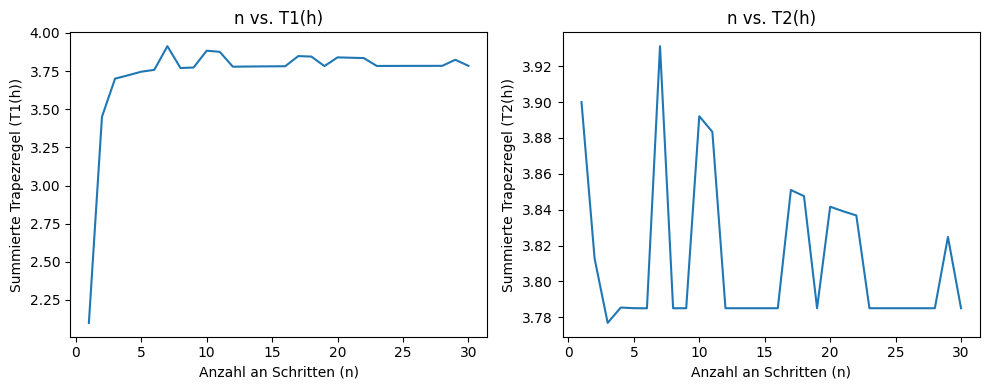

In [7]:
# c) Plotten Sie T1(h) und T2(h) fur n = 1, 2, ..., 30
n_list = list(range(1, 31))

# Alle Ti(h) Werte berechnen
T1_h_list = [rule_sum_step(trapezoid, f, lims, n) for n in n_list]
T2_h_list = [rule_sum_step(simpson, f, lims, n) for n in n_list]

# Ich moechte ein einziges Window mit 2 Graphiken
fig, (plot1, plot2) = plt.subplots(1, 2, figsize=(10, 4))

plot1.plot(n_list, T1_h_list)
plot1.set_title('n vs. T1(h)')
plot1.set_xlabel('Anzahl an Schritten (n)')
plot1.set_ylabel('Summierte Trapezregel (T1(h))')


plot2.plot(n_list, T2_h_list)
plot2.set_title('n vs. T2(h)')
plot2.set_xlabel('Anzahl an Schritten (n)')
plot2.set_ylabel('Summierte Trapezregel (T2(h))')

plt.tight_layout()

plt.show()

In [8]:
# d) Implementieren Sie die Extrapolation fuer die Simpson-Regel...

# x, x_{k}, x_{k+m}, p_{k+1,...,k+m}, p_{k,...,k+m-1}
def linterm(x, x_k, x_kpm, p_kp1_kpm, p_k_kpmm1):
    return ((x - x_k) * p_kp1_kpm - (x - x_kpm) * p_k_kpmm1) / (x_kpm - x_k)

# Wenn es einen Zettel mit einer Implementation des Neville-Verfahrens gab, hab ich den nicht getan
def neville(x, points):
    if len(points) == 0:
        return

    n = len(points)

    # pi[k] = p_{k,..., k + m - 1}
    # es gibt ein implizites "sliding window" von m - 1 Schritten 
    # bei jeder position
    pi = [y for [_, y] in points] # p0...pn

    for m in range(1, n): # range macht nur bis <         
        for k in range(n - m):
            x_k, _   = points[k]
            x_kpm, _ = points[k + m]
            p_kp1_kpm  = pi[k + 1]
            p_k_kpmm1  = pi[k]

            # !! DEBUG !!
            # print(f"x_k: {x_k}, x_kpm: {x_kpm}, p_kp1_kpm: {p_kp1_kpm}, p_k_kpmm1: {p_k_kpmm1}")
            
            pi[k] = linterm(x, x_k, x_kpm, p_kp1_kpm, p_k_kpmm1)
        
        # !! DEBUG !!
        #print(f"iter:{m} - {pi}")

    return pi[0]
        

In [9]:
# ... wobei Sie die Burlisch-Folge benutzen
def burlisch(h, j):
    cj = 1
    while cj < j:
        yield h / cj
        cj += 1 

In [11]:
# ... Waehlen Sie gamma = 4
[a, b] = lims
h = (b - a) / 2
hseq = list(burlisch(h, 5)) # waere es nicht fuer T2(h5)...
gamma = 4

points = [(h**gamma, rule_sum_h(simpson, f, lims, h)) for h in hseq]
t0 = neville(0, points)
T2_h5 = rule_sum_h(simpson, f, lims, hseq[-1])

print(f"t0 (extrapoliert): {t0} vs T2(h5): {T2_h5}")

t0 (extrapoliert): 3.7851113349512504 vs T2(h5): 3.7850898754374396
